# Data preprocessing
---------------------

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("D:\\python_program\\car_price_prediction\\Dataset\\car data.csv")

In [19]:
df.duplicated().sum()

np.int64(2)

In [20]:
df[df.duplicated(keep=False)]       # shows duplicate records
df.drop_duplicates()                 # delete duplicate records

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [21]:
df.isnull().sum()           # Missing values

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

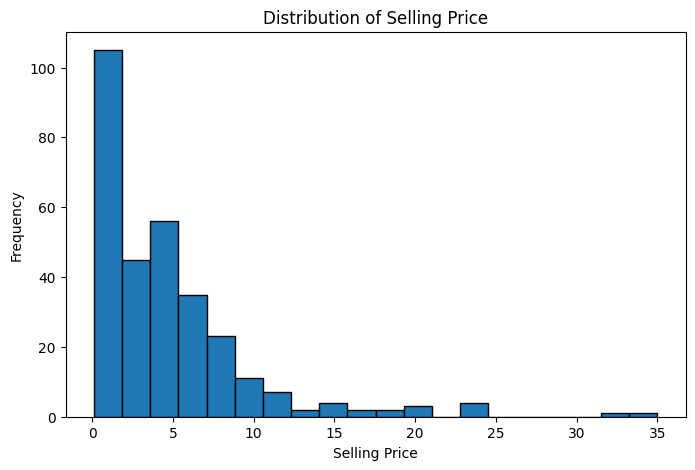

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df["Selling_Price"], bins=20, edgecolor="black")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\selling_price_distribution.png") # should be saved before plt.show() to avoid saving a blank image
plt.show()

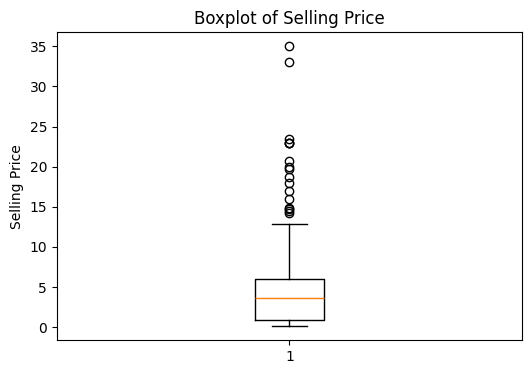

In [27]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Selling_Price"])
plt.title("Boxplot of Selling Price")
plt.ylabel("Selling Price")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\selling_price_boxplot.png") 
plt.show()


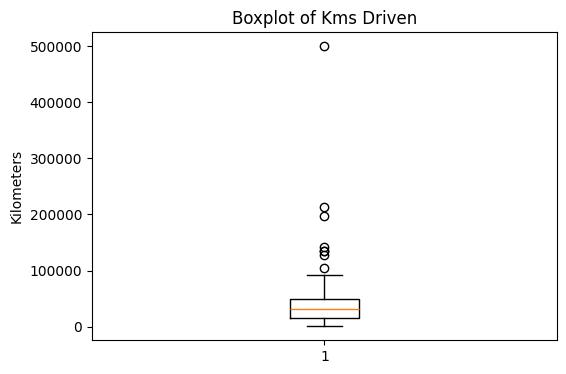

In [28]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Kms_Driven"])
plt.title("Boxplot of Kms Driven")
plt.ylabel("Kilometers")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\kms_driven_boxplot.png")
plt.show()

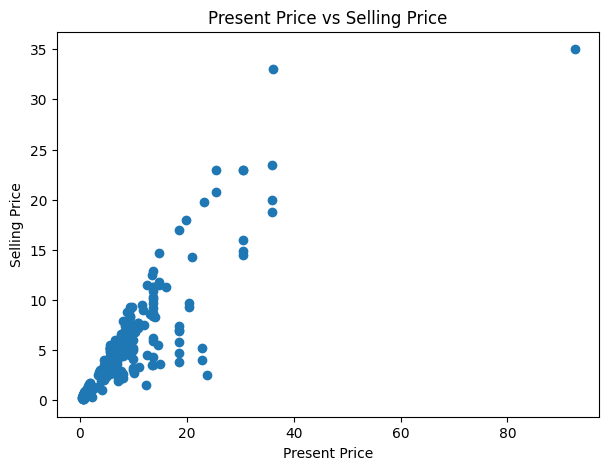

In [29]:
plt.figure(figsize=(7,5))
plt.scatter(df["Present_Price"], df["Selling_Price"])
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\present_price_vs_selling_price.png")
plt.show()

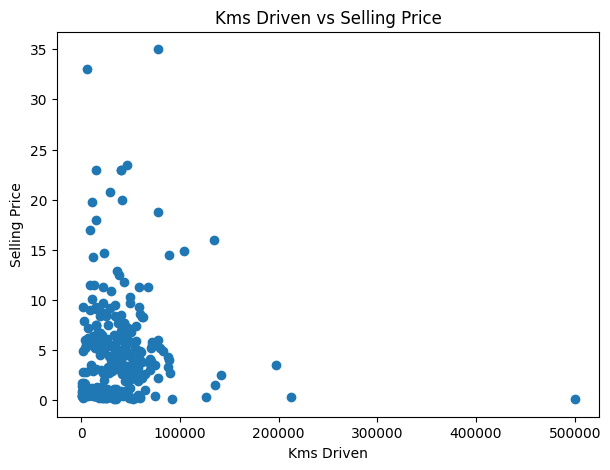

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(df["Kms_Driven"], df["Selling_Price"])
plt.title("Kms Driven vs Selling Price")
plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\kms_driven_vs_selling_price.png")
plt.show()

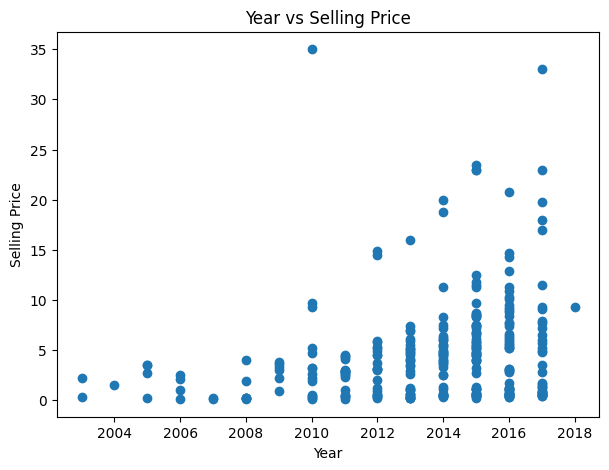

In [31]:
plt.figure(figsize=(7,5))
plt.scatter(df["Year"], df["Selling_Price"])
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\year_vs_selling_price.png")
plt.show()

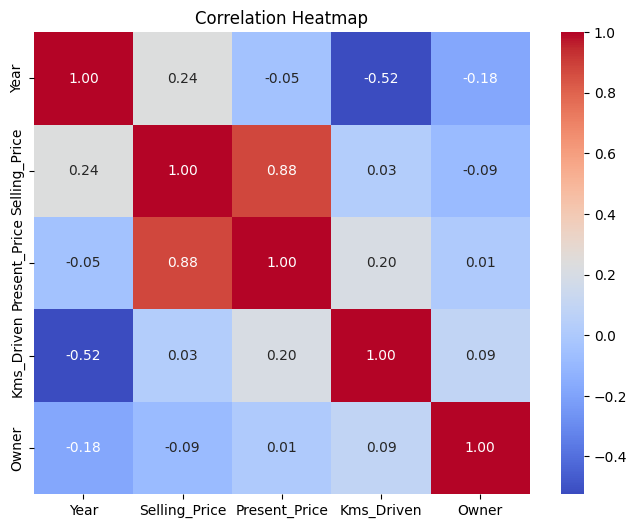

In [33]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("D:\\python_program\\car_price_prediction\\Graphs\\correlation_heatmap.png")
plt.show()

In [34]:
# Create Car_Age feature
df["Car_Age"] = 2025 - df["Year"]
print(df[["Year", "Car_Age"]].head())

   Year  Car_Age
0  2014       11
1  2013       12
2  2017        8
3  2011       14
4  2014       11


In [35]:
# Create Mileage_per_Year feature
df["Mileage_per_Year"] = df["Kms_Driven"] / (df["Car_Age"] + 1)

print(df[["Kms_Driven", "Car_Age", "Mileage_per_Year"]].head())

   Kms_Driven  Car_Age  Mileage_per_Year
0       27000       11       2250.000000
1       43000       12       3307.692308
2        6900        8        766.666667
3        5200       14        346.666667
4       42450       11       3537.500000


In [36]:
# List of premium brands
premium_brands = ["Toyota", "Honda", "Hyundai", "BMW", "Audi", "Mercedes"]

# Create Premium_Brand feature
df["Premium_Brand"] = df["Car_Name"].apply(
    lambda x: 1 if x.split()[0] in premium_brands else 0
)

print(df[["Car_Name", "Premium_Brand"]].head())

  Car_Name  Premium_Brand
0     ritz              0
1      sx4              0
2     ciaz              0
3  wagon r              0
4    swift              0


In [37]:
# Calculate median
median_kms = df["Kms_Driven"].median()

# Create High_Mileage feature
df["High_Mileage"] = (df["Kms_Driven"] > median_kms).astype(int)

print(df[["Kms_Driven", "High_Mileage"]].head())

   Kms_Driven  High_Mileage
0       27000             0
1       43000             1
2        6900             0
3        5200             0
4       42450             1


In [38]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age',
       'Mileage_per_Year', 'Premium_Brand', 'High_Mileage'],
      dtype='str')


# Data Transformation(encoding)

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [40]:
df["Car_Name"] = le.fit_transform(df["Car_Name"])

print(df["Car_Name"].head())

0    90
1    93
2    68
3    96
4    92
Name: Car_Name, dtype: int64


In [41]:
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])

print(df["Fuel_Type"].head())

0    2
1    1
2    2
3    2
4    1
Name: Fuel_Type, dtype: int64


In [42]:
df["Seller_Type"] = le.fit_transform(df["Seller_Type"])

print(df["Seller_Type"].head())

0    0
1    0
2    0
3    0
4    0
Name: Seller_Type, dtype: int64


In [43]:
df["Transmission"] = le.fit_transform(df["Transmission"])

print(df["Transmission"].head())

0    1
1    1
2    1
3    1
4    1
Name: Transmission, dtype: int64


In [44]:
print(df.head().T)
print(df.dtypes)

                         0             1            2            3         4
Car_Name             90.00     93.000000    68.000000    96.000000     92.00
Year               2014.00   2013.000000  2017.000000  2011.000000   2014.00
Selling_Price         3.35      4.750000     7.250000     2.850000      4.60
Present_Price         5.59      9.540000     9.850000     4.150000      6.87
Kms_Driven        27000.00  43000.000000  6900.000000  5200.000000  42450.00
Fuel_Type             2.00      1.000000     2.000000     2.000000      1.00
Seller_Type           0.00      0.000000     0.000000     0.000000      0.00
Transmission          1.00      1.000000     1.000000     1.000000      1.00
Owner                 0.00      0.000000     0.000000     0.000000      0.00
Car_Age              11.00     12.000000     8.000000    14.000000     11.00
Mileage_per_Year   2250.00   3307.692308   766.666667   346.666667   3537.50
Premium_Brand         0.00      0.000000     0.000000     0.000000      0.00

In [45]:
df.to_csv("D:\\python_program\\car_price_prediction\\Dataset\\car_data_preprocessed.csv", index=False)